<a href="https://colab.research.google.com/github/vhousos/EKPA/blob/main/chousos_ids_ips.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

General Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical




Load the csv file from Mr Demertzis github repository, and analyze the available headers. Separate features/labels - MIN/MAX normalization - Define Test, Train and Validation data

In [2]:
def loadDataset():
    filename = "https://raw.githubusercontent.com/kdemertzis/EKPA/main/Data/pcap_data.csv"
    df = pd.read_csv(filename)
    df.head()

    X = df.drop('target', axis=1).to_numpy().astype('float32')
    y = df['target'].to_numpy().astype('int32')

    # Min-Max scaling
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    # Test data 20%
    train_data, test_data, train_label, test_label = train_test_split(
        X_scaled, y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # Train 70%, Validation 10% (0.125 * 80% ≈ 10% συνολικά)
    train_data, val_data, train_label, val_label = train_test_split(
        train_data, train_label,
        test_size=0.125,
        stratify=train_label,
        random_state=42
    )

    return (
        train_data.astype('float32'),
        train_label.astype('int32'),
        val_data.astype('float32'),
        val_label.astype('int32'),
        test_data.astype('float32'),
        test_label.astype('int32')
    )

Define the Dense Model - Load Data - simple Dense Neural Network for 3-class classification and load the preprocessed dataset.

In [3]:
from sklearn.model_selection import train_test_split

def build_dense_model(input_dim, n_classes=3, lr=1e-3):
    """
    Δημιουργεί ένα απλό Dense νευρωνικό δίκτυο για ταξινόμηση 3 κλάσεων.
    """
    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(n_classes, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


train_data, train_labelp, val_data, val_labelp, test_data, test_labelp = loadDataset()

Transform to one-hot  - Class balancing weghts - Callbacks

In [4]:
from sklearn.preprocessing import StandardScaler

nclass = 3
train_label = to_categorical(train_labelp, nclass)
val_label   = to_categorical(val_labelp,   nclass)
test_label  = to_categorical(test_labelp,  nclass)

print('train_data.shape=', train_data.shape)
print('test_data.shape=',  test_data.shape)
print('val_data.shape=',   val_data.shape)

# get the number of features
inshape = train_data.shape[1]





class_weights_raw = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labelp),
    y=train_labelp
)
class_weights = {i: class_weights_raw[i] for i in range(len(class_weights_raw))}
print("class_weights:", class_weights)






os.makedirs('./savemodels', exist_ok=True)

earlyStopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    verbose=1,
    mode='min',
    restore_best_weights=True
)

modelCheckPoint = ModelCheckpoint(
    filepath='./savemodels/model_pcap_best.{epoch:03d}-{val_accuracy:.4f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

train_data.shape= (10476, 25)
test_data.shape= (2994, 25)
val_data.shape= (1497, 25)
class_weights: {0: np.float64(0.9974293059125964), 1: np.float64(0.9954389965792474), 2: np.float64(1.007210845111047)}


Create and train the model - Load the best model from "savedmodels"

In [5]:
epochs = 100
batch_size = 256

model = build_dense_model(input_dim=inshape, n_classes=nclass, lr=1e-3)
model.summary()

history = model.fit(
    train_data, train_label,
    shuffle=True,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(val_data, val_label),
    class_weight=class_weights,
    callbacks=[modelCheckPoint, earlyStopping]
)



str_models = os.listdir('./savemodels')
str_models = np.sort(str_models)
best_model = str_models[-1]
print('best_model =', best_model)

model.load_weights('./savemodels/' + best_model)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,779 (46.01 KB)

 Trainable params: 11,779 (46.01 KB)

...

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9073 - loss: 0.3567 - val_accuracy: 0.9025 - val_loss: 0.3967
Epoch 59/100
30/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9044 - loss: 0.3555
Epoch 59: val_accuracy did not improve from 0.90247
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9043 - loss: 0.3581 - val_accuracy: 0.8985 - val_loss: 0.3928
Epoch 60/100
34/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9071 - loss: 0.3626
Epoch 60: val_accuracy did not improve from 0.90247
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9069 - loss: 0.3618 - val_accuracy: 0.8998 - val_loss: 0.3976
Epoch 61/100
29/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9141 - loss: 0.3431
Epoch 61: val_accuracy did not improve from 0.90247
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9122 - loss: 0.3470 - val_accuracy: 0.8918 - val_loss: 0.3956
Epoch 62/100
35/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9024 - loss: 0.3704
Epoch 62: val_accuracy did not improve f

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9083 - loss: 0.3541 - val_accuracy: 0.9031 - val_loss: 0.3906
Epoch 64/100
35/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9127 - loss: 0.3348
Epoch 64: val_accuracy did not improve from 0.90314
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9117 - loss: 0.3380 - val_accuracy: 0.8925 - val_loss: 0.3945
Epoch 65/100
34/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9106 - loss: 0.3464
Epoch 65: val_accuracy did not improve from 0.90314
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9098 - loss: 0.3485 - val_accuracy: 0.9025 - val_loss: 0.3911
Epoch 66/100
34/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9063 - loss: 0.3518
Epoch 66: val_accuracy did not improve from 0.90314
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9064 - loss: 0.3524 - val_accuracy: 0.8965 - val_loss: 0.3955
Epoch 67/100
37/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9045 - loss: 0.3606
Epoch 67: val_accuracy did not improve f

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9140 - loss: 0.3382 - val_accuracy: 0.9038 - val_loss: 0.3928
Epoch 87/100
32/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9142 - loss: 0.3389
Epoch 87: val_accuracy did not improve from 0.90381
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9135 - loss: 0.3404 - val_accuracy: 0.8991 - val_loss: 0.3872
Epoch 88/100
30/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9197 - loss: 0.3295
Epoch 88: val_accuracy did not improve from 0.90381
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9184 - loss: 0.3329 - val_accuracy: 0.9005 - val_loss: 0.3879
Epoch 89/100
31/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9150 - loss: 0.3373
Epoch 89: val_accuracy did not improve from 0.90381
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9143 - loss: 0.3388 - val_accuracy: 0.9025 - val_loss: 0.3885
Epoch 90/100
34/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9189 - loss: 0.3318
Epoch 90: val_accuracy improved from 0.9

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9178 - loss: 0.3341 - val_accuracy: 0.9051 - val_loss: 0.3853
Epoch 91/100
39/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9096 - loss: 0.3538
Epoch 91: val_accuracy did not improve from 0.90514
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9098 - loss: 0.3527 - val_accuracy: 0.9018 - val_loss: 0.3848
Epoch 92/100
23/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9101 - loss: 0.3483 
Epoch 92: val_accuracy did not improve from 0.90514
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9121 - loss: 0.3436 - val_accuracy: 0.9038 - val_loss: 0.3867
Epoch 93/100
34/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9132 - loss: 0.3353
Epoch 93: val_accuracy did not improve from 0.90514
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9132 - loss: 0.3353 - val_accuracy: 0.9038 - val_loss: 0.3904
Epoch 94/100
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9129 - loss: 0.3324
Epoch 94: val_accuracy did not improve 

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9165 - loss: 0.3260 - val_accuracy: 0.9058 - val_loss: 0.3862
Epoch 100/100
38/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9128 - loss: 0.3431
Epoch 100: val_accuracy did not improve from 0.90581
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9127 - loss: 0.3426 - val_accuracy: 0.9011 - val_loss: 0.3925
Restoring model weights from the end of the best epoch: 98.
best_model = model_pcap_best.099-0.9058.h5


Confusion matrix to "test" set - Plotting the confusion matrix

TEST DATA - Confusion matrix:
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
[[902  53  46]
 [ 44 917  42]
 [ 42  25 923]]
Accuracy ratios for each class
Normal (0) = 0.9011
Anomaly (1) = 0.9143
Attack (2) = 0.9323


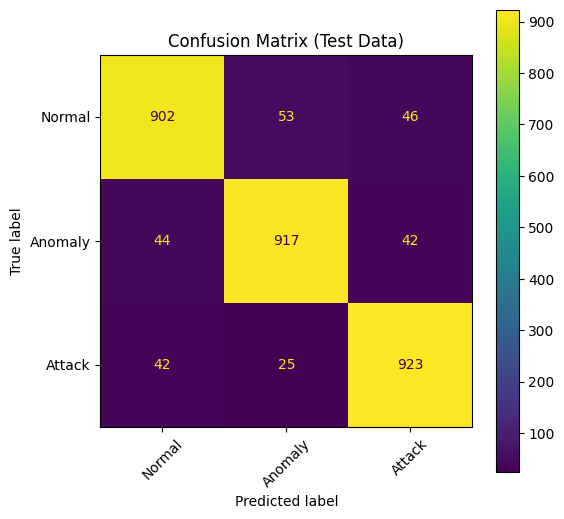

In [6]:
print('TEST DATA - Confusion matrix:')

pred = model.predict(test_data)
pred_y = np.argmax(pred, axis=1)

cm = confusion_matrix(test_labelp.astype('int32'), pred_y)
print(cm)

print('Accuracy ratios for each class')
for i, cls_name in enumerate(['Normal (0)', 'Anomaly (1)', 'Attack (2)']):
    acc_i = cm[i, i] / np.sum(cm[i, :])
    print(f'{cls_name} = {acc_i:.4f}')





label_names = np.array(['Normal', 'Anomaly', 'Attack'])

cmo = ConfusionMatrixDisplay(cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(6, 6))
cmo.plot(ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix (Test Data)')
plt.show()

Convert IDS predictions into preventive IPS actions (allow, alert, block).

In [7]:
# === IPS Decision Engine ===

def ips_decision_engine(predicted_class):
    """
    Μετατρέπει την πρόβλεψη του IDS σε ενέργεια IPS.
    0 = Normal  → ALLOW
    1 = Anomaly → ALERT_AND_MONITOR
    2 = Attack  → BLOCK_AND_NOTIFY
    """
    if predicted_class == 0:
        return "ALLOW"
    elif predicted_class == 1:
        return "ALERT_AND_MONITOR"
    elif predicted_class == 2:
        return "BLOCK_AND_NOTIFY"
    else:
        return "UNKNOWN"


Apply IPS Decisions on Test Data

In [8]:
print("\nIPS DECISIONS ON TEST DATA\n")

ips_actions = []

for i in range(len(test_data)):
    cls = pred_y[i]
    action = ips_decision_engine(cls)
    ips_actions.append(action)
    print(f"Flow {i:04d}: Pred={cls} → Action={action}")



IPS DECISIONS ON TEST DATA

Flow 0000: Pred=1 → Action=ALERT_AND_MONITOR
Flow 0001: Pred=2 → Action=BLOCK_AND_NOTIFY
Flow 0002: Pred=0 → Action=ALLOW
Flow 0003: Pred=1 → Action=ALERT_AND_MONITOR
Flow 0004: Pred=1 → Action=ALERT_AND_MONITOR
Flow 0005: Pred=2 → Action=BLOCK_AND_NOTIFY
Flow 0006: Pred=1 → Action=ALERT_AND_MONITOR
Flow 0007: Pred=2 → Action=BLOCK_AND_NOTIFY
Flow 0008: Pred=2 → Action=BLOCK_AND_NOTIFY
Flow 0009: Pred=2 → Action=BLOCK_AND_NOTIFY
Flow 0010: Pred=1 → Action=ALERT_AND_MONITOR
Flow 0011: Pred=1 → Action=ALERT_AND_MONITOR
Flow 0012: Pred=1 → Action=ALERT_AND_MONITOR
Flow 0013: Pred=2 → Action=BLOCK_AND_NOTIFY
Flow 0014: Pred=2 → Action=BLOCK_AND_NOTIFY
Flow 0015: Pred=1 → Action=ALERT_AND_MONITOR
Flow 0016: Pred=2 → Action=BLOCK_AND_NOTIFY
Flow 0017: Pred=2 → Action=BLOCK_AND_NOTIFY
Flow 0018: Pred=1 → Action=ALERT_AND_MONITOR
Flow 0019: Pred=1 → Action=ALERT_AND_MONITOR
Flow 0020: Pred=0 → Action=ALLOW
Flow 0021: Pred=0 → Action=ALLOW
Flow 0022: Pred=0 → Action

updating the model online based on newly observed attacks (idea taken from OnlineLearning_IPS Mr. Demertzis's file)

In [9]:
# === Online learning component (optional) ===

def online_learning_update(model, feature_vector, true_label):
    """
    Ενημερώνει το μοντέλο με νέο δείγμα – προσομοίωση online learning IPS.
    """
    fv = feature_vector.reshape(1, -1)
    lbl = to_categorical(np.array([true_label]), 3)
    model.fit(fv, lbl, epochs=1, verbose=0)


# Example: update only on detected attacks
for i in range(len(test_data)):
    if pred_y[i] == 2:   # Attack
        online_learning_update(model, test_data[i], pred_y[i])


Confusion Matrix Before & After Online Learning as an IPS Evaluation method....


=== Evaluating IPS BEFORE online learning ===
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy BEFORE online learning: 0.3360

Total online learning updates performed: 1011
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 775us/step
Accuracy AFTER online learning: 0.3333


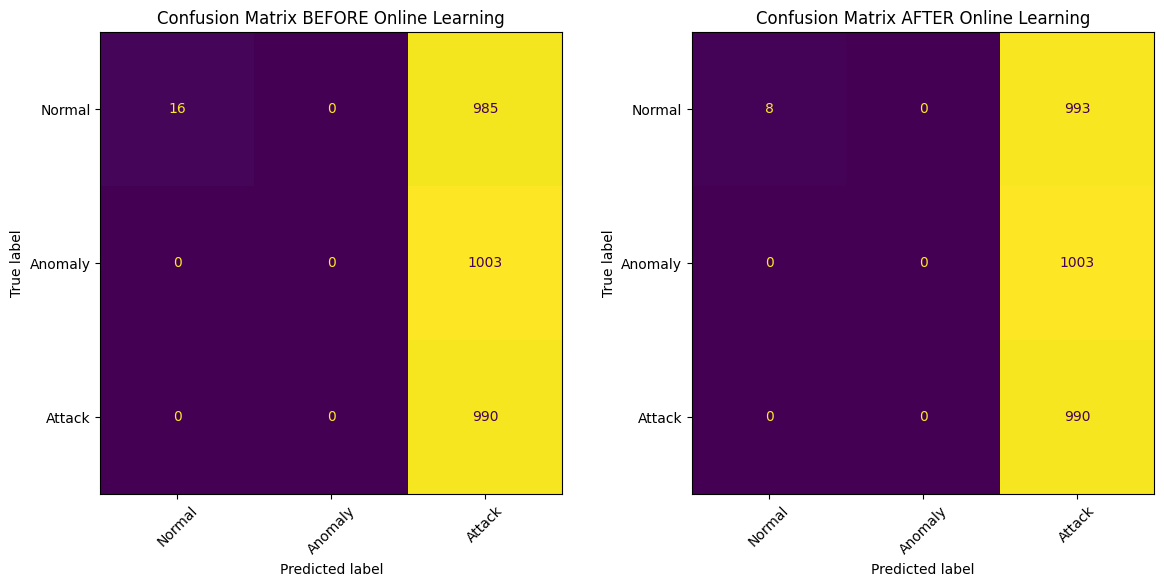

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

print("\n=== Evaluating IPS BEFORE online learning ===")

# Convert one-hot labels → integer labels
test_label_int = np.argmax(test_label, axis=1)

# Predictions BEFORE online learning
pred_before = np.argmax(model.predict(test_data), axis=1)
acc_before = accuracy_score(test_label_int, pred_before)

print(f"Accuracy BEFORE online learning: {acc_before:.4f}")

cm_before = confusion_matrix(test_label_int, pred_before)



###### Before




num_updates = 0

for i in range(len(test_data)):
    if pred_y[i] == 2:   # If predicted Attack
        online_learning_update(model, test_data[i], pred_y[i])
        num_updates += 1

print(f"\nTotal online learning updates performed: {num_updates}")




###### After


pred_after = np.argmax(model.predict(test_data), axis=1)
acc_after = accuracy_score(test_label_int, pred_after)

print(f"Accuracy AFTER online learning: {acc_after:.4f}")

cm_after = confusion_matrix(test_label_int, pred_after)





#Plot


labels = ['Normal', 'Anomaly', 'Attack']

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

disp_before = ConfusionMatrixDisplay(cm_before, display_labels=labels)
disp_before.plot(ax=axs[0], xticks_rotation=45, colorbar=False)
axs[0].set_title("Confusion Matrix BEFORE Online Learning")

disp_after = ConfusionMatrixDisplay(cm_after, display_labels=labels)
disp_after.plot(ax=axs[1], xticks_rotation=45, colorbar=False)
axs[1].set_title("Confusion Matrix AFTER Online Learning")

plt.show()
